# **Stochastic MABs (Part 2)**

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from scipy.stats import beta as beta_dist 
# scipy is to plot the probability density function
# not strictly necessary

### We consider Stochastic MABs with Bernoulli distributions

In [6]:
class Environment:
    def __init__(self):
        pass

    def round(self, a_t):
        pass

In [7]:
class BernoulliEnvironment(Environment):
    def __init__(self, p, T):
        self.K = len(p)
        self.rewards = np.random.binomial(n=1, p=p, size=(T, self.K))
        self.t = 0

    def round(self, a_t):
        r_t = self.rewards[self.t, a_t]
        self.t +=1
        return r_t

### Recall Agent template class and the UCB1 algorithm

In [8]:
# this is the blueprint of an Agent-type class, we can customize this with our strategy
class Agent:
    def __init__(self):
        pass
    def pull_arm(self):
        pass
    def update(self, r_t):
        pass

In [44]:
class UCB1Agent(Agent):
    def __init__(self, K, T, range=1):
        self.K = K
        self.T = T
        self.range = range
        self.a_t = None
        self.average_rewards = np.zeros(K)
        self.N_pulls = np.zeros(K)
        self.t = 0
    
    def pull_arm(self):
        if self.t < self.K:
            self.a_t = self.t 
        else:
            ucbs = self.average_rewards + self.range*np.sqrt(2*np.log(self.T)/self.N_pulls)
            self.a_t = np.argmax(ucbs)
        return self.a_t
    
    def update(self, r_t):
        self.N_pulls[self.a_t] += 1
        self.average_rewards[self.a_t] += (r_t - self.average_rewards[self.a_t])/self.N_pulls[self.a_t]
        self.t += 1

# Anytime Algorithms

### What if we do not kown the time horizon $T$?

### Algorithms that do **not** need the time horizon as input are called **anytime algorithms**.

## Anytime UCB1

### UCB1 is easily convertible to an anytime version: simply replace T by a function of the current time t!

In [45]:
def f(t):
    return 1+(t+1)*np.log(t+1)**2

class AnytimeUCB1Agent(Agent):
    def __init__(self, K, range=1): ### only requires K!
        self.K = K
        self.range = range
        self.a_t = None
        self.average_rewards = np.zeros(K)
        self.N_pulls = np.zeros(K)
        self.t = 0
    
    def pull_arm(self):
        if self.t < self.K:
            self.a_t = self.t 
        else:
            ucbs = self.average_rewards + self.range*np.sqrt(2*np.log(f(self.t))/self.N_pulls)
            self.a_t = np.argmax(ucbs)
        return self.a_t
    
    def update(self, r_t):
        self.N_pulls[self.a_t] += 1
        self.average_rewards[self.a_t] += (r_t - self.average_rewards[self.a_t])/self.N_pulls[self.a_t]
        self.t += 1

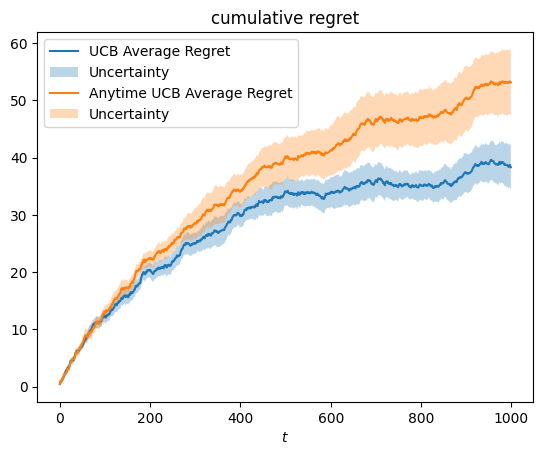

In [46]:
### Same block of code as in Exercise session 1!
p = np.array([0.25, 0.5, 0.75])
K = len(p)
best_action = np.argmax(p)
T = 1000
expected_clairvoyant_rewards = np.repeat(p[best_action], T)

n_trials = 10

ucb_regret_per_trial = []
anytime_ucb_regret_per_trial = []

for seed in range(n_trials):
    np.random.seed(seed)
    env = BernoulliEnvironment(p, T)
    ucb_agent = UCB1Agent(K, T)

    agent_rewards = np.array([])

    for t in range(T):
        a_t = ucb_agent.pull_arm()
        r_t = env.round(a_t)
        ucb_agent.update(r_t)

        agent_rewards = np.append(agent_rewards, r_t)

    cumulative_regret = np.cumsum(expected_clairvoyant_rewards-agent_rewards)
    ucb_regret_per_trial.append(cumulative_regret)

    np.random.seed(seed)
    env = BernoulliEnvironment(p, T)
    anytime_ucb_agent = AnytimeUCB1Agent(K)
    agent_rewards = np.array([])
    for t in range(T):
        a_t = anytime_ucb_agent.pull_arm()
        r_t = env.round(a_t)
        anytime_ucb_agent.update(r_t)

        agent_rewards = np.append(agent_rewards, r_t)

    cumulative_regret = np.cumsum(expected_clairvoyant_rewards-agent_rewards)
    anytime_ucb_regret_per_trial.append(cumulative_regret)


ucb_regret_per_trial = np.array(ucb_regret_per_trial)
anytime_ucb_regret_per_trial = np.array(anytime_ucb_regret_per_trial)

ucb_average_regret = ucb_regret_per_trial.mean(axis=0)
ucb_regret_sd = ucb_regret_per_trial.std(axis=0)

anytime_ucb_average_regret = anytime_ucb_regret_per_trial.mean(axis=0)
anytime_ucb_regret_sd = anytime_ucb_regret_per_trial.std(axis=0)

plt.plot(np.arange(T), ucb_average_regret, label='UCB Average Regret')
plt.fill_between(np.arange(T),
                ucb_average_regret-ucb_regret_sd/np.sqrt(n_trials),
                ucb_average_regret+ucb_regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.plot(np.arange(T), anytime_ucb_average_regret, label='Anytime UCB Average Regret')
plt.fill_between(np.arange(T),
                anytime_ucb_average_regret-anytime_ucb_regret_sd/np.sqrt(n_trials),
                anytime_ucb_average_regret+anytime_ucb_regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.title('cumulative regret')
#plt.plot((0,T-1), (average_regret[0], average_regret[-1]), 'ro', linestyle="--")
plt.xlabel('$t$')
plt.legend()
plt.show()

#plt.barh(y=['0','1','2'], width=ucb_agent.N_pulls)
#plt.title('number of pulls per arm of UCB1')

### Were we expecting this outcome?

# Doubling Trick

### Question: is there a way to convert any algorithm to an anytime version while preserving regret guarantees?

### _Doubling trick_ is a simple way to build an anytime algorithm $\mathcal{A}$ given another that requires $T$: the idea is to restart the algorithm a logarithmic number of times during the trial

### Let $T_i = 2^{i-1}$. Run $\mathcal{A}$ for $T_0$ rounds. Then re-initialize $\mathcal{A}$ and run it for $T_1$ rounds, and so on... 

### The doubling trick is a general method that **works even in adversarial and contextual settings**, we code a general class wrapper that receives an Agent constructor

In [47]:
class DoublingTrickAgent(Agent):
    def __init__(self, K, agent_init):
        self.K = K
        self.agent_init = agent_init
        self.t = 0
        self.i = 1 # number of epoch: T_1= 2**(1-1), T_2 = 2**(2-1) ...
        self.next_phase_start = self.t + 2**(self.i-1)
        self.current_agent = self.agent_init(K,2**(self.i-1))
    
    def pull_arm(self):
        return self.current_agent.pull_arm()
    
    def update(self, r_t):
        self.current_agent.update(r_t)
        self.t += 1
        if self.t == self.next_phase_start:
            self.i += 1
            T_i = 2**(self.i-1)
            self.next_phase_start = self.t + T_i
            self.current_agent = self.agent_init(self.K, T_i)

### Let's try it with UCB1

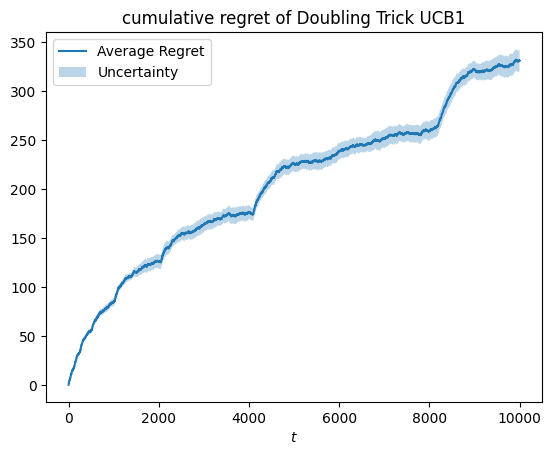

In [48]:
p = np.array([0.25, 0.5, 0.75])
K = len(p)
best_action = np.argmax(p)
T = 10000
expected_clairvoyant_rewards = np.repeat(p[best_action], T)

n_trials = 10

regret_per_trial = []

for seed in range(n_trials):
    np.random.seed(seed)
    env = BernoulliEnvironment(p, T)
    dt_ucb_agent = DoublingTrickAgent(K, UCB1Agent) ### doesn't require T

    agent_rewards = np.array([])

    for t in range(T):
        a_t = dt_ucb_agent.pull_arm()
        r_t = env.round(a_t)
        dt_ucb_agent.update(r_t)

        agent_rewards = np.append(agent_rewards, r_t)

    cumulative_regret = np.cumsum(expected_clairvoyant_rewards-agent_rewards)
    regret_per_trial.append(cumulative_regret)

regret_per_trial = np.array(regret_per_trial)

average_regret = regret_per_trial.mean(axis=0)
regret_sd = regret_per_trial.std(axis=0)

plt.plot(np.arange(T), average_regret, label='Average Regret')
plt.title('cumulative regret of Doubling Trick UCB1')
plt.fill_between(np.arange(T),
                average_regret-regret_sd/np.sqrt(n_trials),
                average_regret+regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
#plt.plot((0,T-1), (average_regret[0], average_regret[-1]), 'ro', linestyle="--")
plt.xlabel('$t$')
plt.legend()
plt.show()

### Explanations for this shape?

### Visual representation of confidence intervals shrinking **and expanding**

/var/folders/4h/m7h4lrd53d15wcxksyytrdqh0000gn/T/ipykernel_63730/3056481757.py:2: RuntimeWarning: divide by zero encountered in log
  return 1+t*np.log(t)**2
/var/folders/4h/m7h4lrd53d15wcxksyytrdqh0000gn/T/ipykernel_63730/3056481757.py:2: RuntimeWarning: invalid value encountered in scalar multiply
  return 1+t*np.log(t)**2


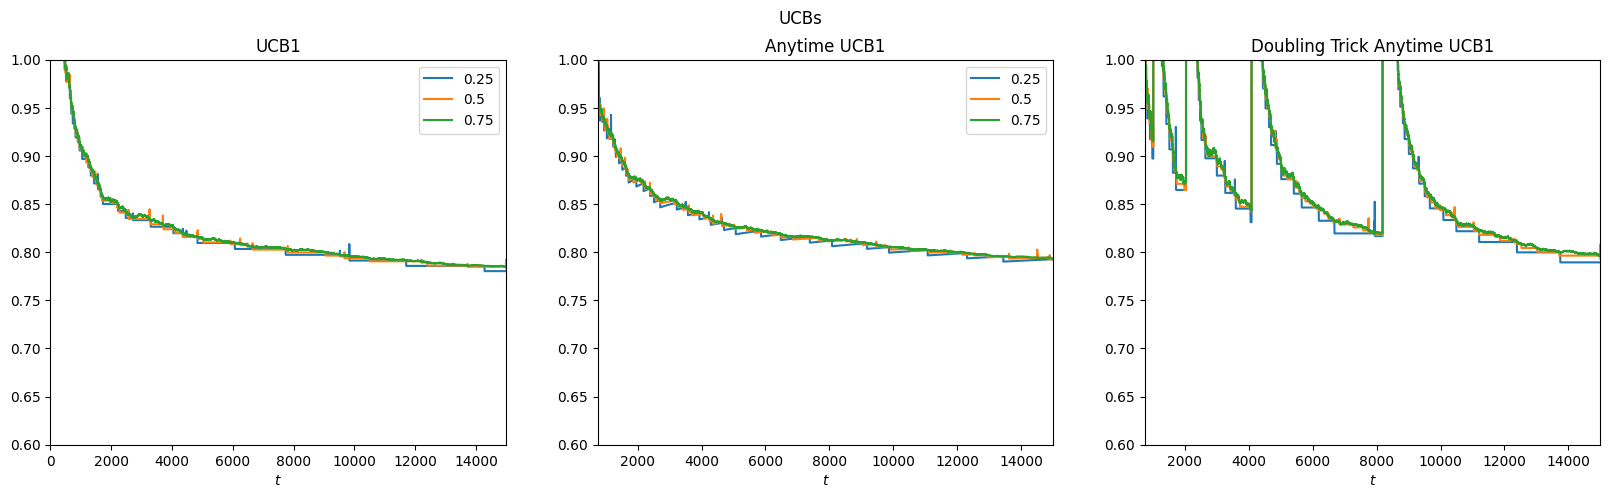

In [68]:
seed = 17
T=15000
np.random.seed(seed)
env = BernoulliEnvironment(p, T)
np.random.seed(seed)
anytime_env = BernoulliEnvironment(p, T)
np.random.seed(seed)
dt_env = BernoulliEnvironment(p, T)

ucb_agent = UCB1Agent(K, T)
anytime_ucb_agent = AnytimeUCB1Agent(K)
dt_ucb_agent = DoublingTrickAgent(K, UCB1Agent)

ci_widths = np.zeros((T,K))
curr_average = np.zeros((T,K))

anytime_ci_widths = np.zeros((T,K))
anytime_curr_average = np.zeros((T,K))

dt_ci_widths = np.zeros((T,K))
dt_curr_average = np.zeros((T,K))

for t in range(T):
    a_t = ucb_agent.pull_arm()
    r_t = env.round(a_t)
    ucb_agent.update(r_t)

    ci_widths[t,:] = np.sqrt(2*np.log(T)/np.maximum(ucb_agent.N_pulls,0.01))
    curr_average[t,:] = curr_average[t-1,:]
    curr_average[t,a_t] += (r_t - curr_average[t,a_t])/ucb_agent.N_pulls[a_t]

    a_t = anytime_ucb_agent.pull_arm()
    r_t = anytime_env.round(a_t)
    anytime_ucb_agent.update(r_t)

    anytime_ci_widths[t,:] = np.sqrt(2*np.log(f(t))/np.maximum(anytime_ucb_agent.N_pulls,0.01))
    anytime_curr_average[t,:] = anytime_curr_average[t-1,:]
    anytime_curr_average[t,a_t] += (r_t - anytime_curr_average[t,a_t])/anytime_ucb_agent.N_pulls[a_t]

    a_t = dt_ucb_agent.pull_arm()
    r_t = dt_env.round(a_t)
    dt_ucb_agent.update(r_t)

    dt_ci_widths[t,:] = np.clip(np.sqrt(2*np.log(2**(dt_ucb_agent.i-1))/np.maximum(dt_ucb_agent.current_agent.N_pulls,0.01)), a_min=0, a_max=1)
    dt_curr_average[t,:] = dt_curr_average[t-1,:]
    dt_curr_average[t,a_t] += (r_t - dt_curr_average[t,a_t])/np.maximum(dt_ucb_agent.current_agent.N_pulls[a_t], 0.01)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3,figsize=(20,5))
fig.suptitle('UCBs')

ax1.plot(curr_average+ci_widths,label=p)
ax1.set_title('UCB1')
ax1.set_xlabel('$t$')
ax1.set_ylim(0.6,1)
ax1.set_xlim(0, T)
ax1.legend()

ax2.plot(anytime_curr_average+anytime_ci_widths,label=p)
ax2.set_title('Anytime UCB1')
ax2.set_xlabel('$t$')
ax2.set_ylim(0.6,1)
ax2.set_xlim(T/20, T)

ax3.plot(dt_curr_average+dt_ci_widths,label=p)
ax3.set_title('Doubling Trick Anytime UCB1')
ax3.set_xlabel('$t$')
ax3.set_ylim(0.6,1)
ax3.set_xlim(T/20, T)

ax2.legend()

plt.show();

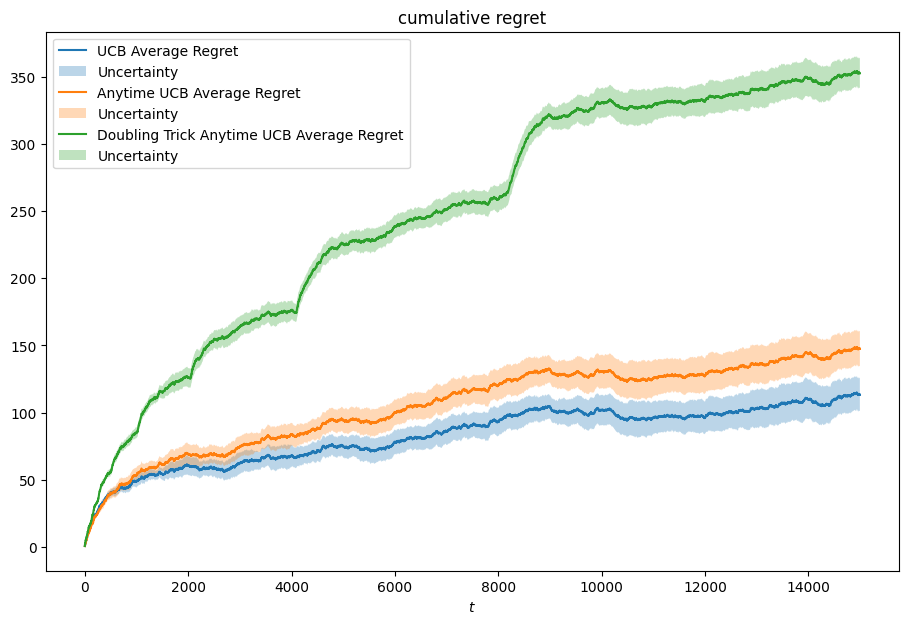

In [77]:
### Same block of code as in Exercise session 1!
p = np.array([0.25, 0.5, 0.75])
K = len(p)
best_action = np.argmax(p)
T = 15000
expected_clairvoyant_rewards = np.repeat(p[best_action], T)

n_trials = 10

ucb_regret_per_trial = []
anytime_ucb_regret_per_trial = []
dt_ucb_regret_per_trial = []

for seed in range(n_trials):
    np.random.seed(seed)
    env = BernoulliEnvironment(p, T)
    ucb_agent = UCB1Agent(K, T)

    agent_rewards = np.array([])

    for t in range(T):
        a_t = ucb_agent.pull_arm()
        r_t = env.round(a_t)
        ucb_agent.update(r_t)

        agent_rewards = np.append(agent_rewards, r_t)

    cumulative_regret = np.cumsum(expected_clairvoyant_rewards-agent_rewards)
    ucb_regret_per_trial.append(cumulative_regret)

    np.random.seed(seed)
    env = BernoulliEnvironment(p, T)
    anytime_ucb_agent = AnytimeUCB1Agent(K)
    agent_rewards = np.array([])
    for t in range(T):
        a_t = anytime_ucb_agent.pull_arm()
        r_t = env.round(a_t)
        anytime_ucb_agent.update(r_t)

        agent_rewards = np.append(agent_rewards, r_t)

    cumulative_regret = np.cumsum(expected_clairvoyant_rewards-agent_rewards)
    anytime_ucb_regret_per_trial.append(cumulative_regret)

    np.random.seed(seed)
    env = BernoulliEnvironment(p, T)
    dt_ucb_agent = DoublingTrickAgent(K, UCB1Agent)
    agent_rewards = np.array([])
    for t in range(T):
        a_t = dt_ucb_agent.pull_arm()
        r_t = env.round(a_t)
        dt_ucb_agent.update(r_t)

        agent_rewards = np.append(agent_rewards, r_t)

    cumulative_regret = np.cumsum(expected_clairvoyant_rewards-agent_rewards)
    dt_ucb_regret_per_trial.append(cumulative_regret)


ucb_regret_per_trial = np.array(ucb_regret_per_trial)
anytime_ucb_regret_per_trial = np.array(anytime_ucb_regret_per_trial)
dt_ucb_regret_per_trial = np.array(dt_ucb_regret_per_trial)

ucb_average_regret = ucb_regret_per_trial.mean(axis=0)
ucb_regret_sd = ucb_regret_per_trial.std(axis=0)

anytime_ucb_average_regret = anytime_ucb_regret_per_trial.mean(axis=0)
anytime_ucb_regret_sd = anytime_ucb_regret_per_trial.std(axis=0)

dt_ucb_average_regret = dt_ucb_regret_per_trial.mean(axis=0)
dt_ucb_regret_sd = dt_ucb_regret_per_trial.std(axis=0)

plt.figure(figsize=(11,7))
plt.plot(np.arange(T), ucb_average_regret, label='UCB Average Regret')
plt.fill_between(np.arange(T),
                ucb_average_regret-ucb_regret_sd/np.sqrt(n_trials),
                ucb_average_regret+ucb_regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.plot(np.arange(T), anytime_ucb_average_regret, label='Anytime UCB Average Regret')
plt.fill_between(np.arange(T),
                anytime_ucb_average_regret-anytime_ucb_regret_sd/np.sqrt(n_trials),
                anytime_ucb_average_regret+anytime_ucb_regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.plot(np.arange(T), dt_ucb_average_regret, label='Doubling Trick Anytime UCB Average Regret')
plt.fill_between(np.arange(T),
                dt_ucb_average_regret-dt_ucb_regret_sd/np.sqrt(n_trials),
                dt_ucb_average_regret+dt_ucb_regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.title('cumulative regret')
plt.xlabel('$t$')
plt.legend()
plt.show();

## **The Thompson Sampling Algorithm**

### UCB1 is a deterministic algorithm, i.e., given the same sequence of rewards the chosen actions will always be the same. It has been observed that often, in practice, randomized algorithm can perform better.

### We thus introduce Thompson Sampling, an algorithm having similar theoretical guarantees of UCB1, but taking randomized decisions.

In [79]:
class TSAgent(Agent):
    def __init__(self, K): # no T required -> naturally an anytime algorithm
        self.K = K
        self.a_t = None
        self.alpha, self.beta = np.ones(K), np.ones(K) # uniform prior
        # logging
        self.N_pulls = np.zeros(K)
        self.theta = []

    def pull_arm(self):
        theta = np.random.beta(self.alpha, self.beta) # sampling from posterior
        self.theta.append(theta)
        self.a_t = np.argmax(theta)
        return self.a_t
    
    def update(self, r_t):
        self.alpha[self.a_t] += r_t  # posterior update
        self.beta[self.a_t] += 1-r_t # posterior update
        self.N_pulls[self.a_t] += 1  # not really necessary, but useful for logging

### We estimate the pseudo-regret:

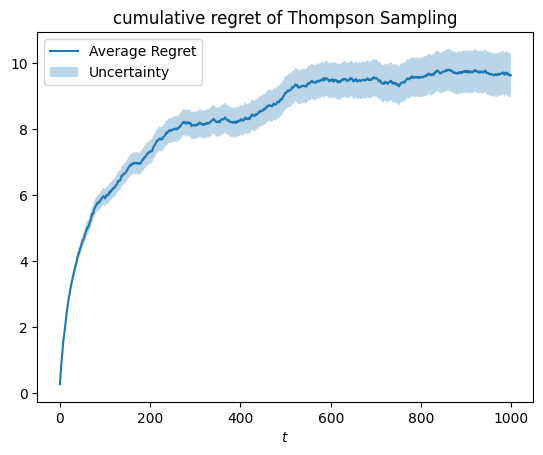

In [ ]:
p = np.array([0.25, 0.5, 0.75])
K = len(p)
best_action = np.argmax(p)
T = 1000
expected_clairvoyant_rewards = np.repeat(p[best_action], T)

n_trials = 100 # needed for consistent evaluation! randomized algos are less stable

regret_per_trial = []

for seed in range(n_trials): #setting the seed is particularly crucial for randomized algorithms
    np.random.seed(seed)
    env = BernoulliEnvironment(p, T)
    ts_agent = TSAgent(K) ### doesn't require T

    agent_rewards = np.array([])

    for t in range(T):
        a_t = ts_agent.pull_arm()
        r_t = env.round(a_t)
        ts_agent.update(r_t)

        agent_rewards = np.append(agent_rewards, r_t)

    cumulative_regret = np.cumsum(expected_clairvoyant_rewards-agent_rewards)
    regret_per_trial.append(cumulative_regret)

regret_per_trial = np.array(regret_per_trial)

average_regret = regret_per_trial.mean(axis=0)
regret_sd = regret_per_trial.std(axis=0)

plt.plot(np.arange(T), average_regret, label='Average Regret')
plt.title('cumulative regret of Thompson Sampling')
plt.fill_between(np.arange(T),
                average_regret-regret_sd/np.sqrt(n_trials),
                average_regret+regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')

plt.xlabel('$t$')
plt.legend()
plt.show()

### Visualization of the density functions

In [99]:
# utility function to visualize the pdf of a Beta distribution
def plot_beta(alpha, beta, ax, samples=100, use_scipy=True, title=None):
    x = np.linspace(0,1,samples)
    y = (x**(alpha-1)) * ((1-x)**(beta-1))
    if use_scipy:
        y = beta_dist.pdf(x, alpha, beta) 
    else:
        beta_const_approx = np.sum(y*(1/samples)) # approximation
        y = y / beta_const_approx
    ax.plot(x,y)
    ax.set_title(title)
    ax.fill_between(x,y,alpha=0.3)

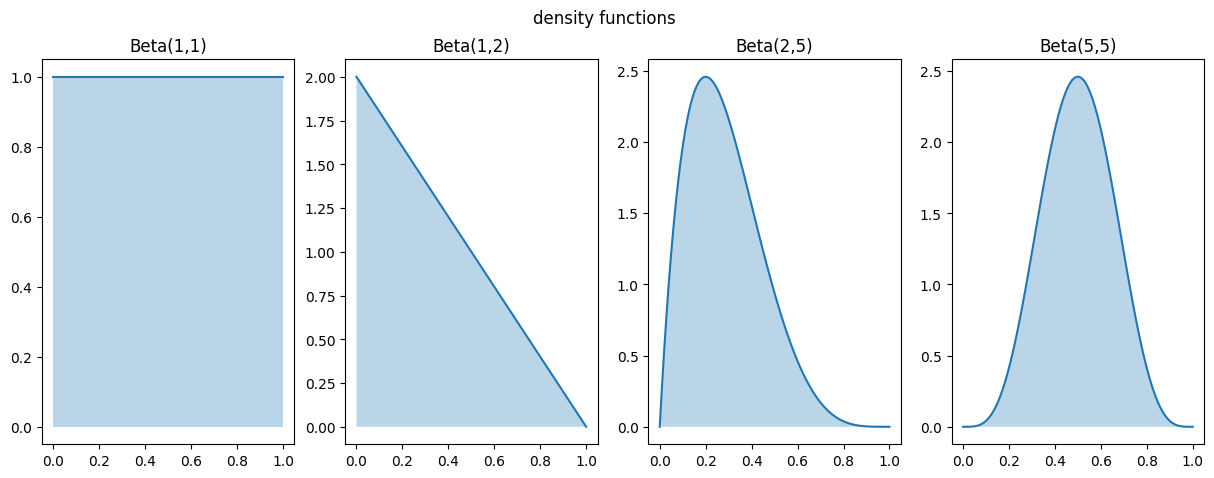

In [100]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4,figsize=(15,5))
fig.suptitle('density functions')
plot_beta(1, 1, ax1, title='Beta(1,1)')
plot_beta(1, 2, ax2, title='Beta(1,2)')
plot_beta(2, 5, ax3, title='Beta(2,5)')
plot_beta(5, 5, ax4, title='Beta(5,5)') # the closer alpha and beta are, the closer it is to a Bernoulli(0.5)
plt.show()

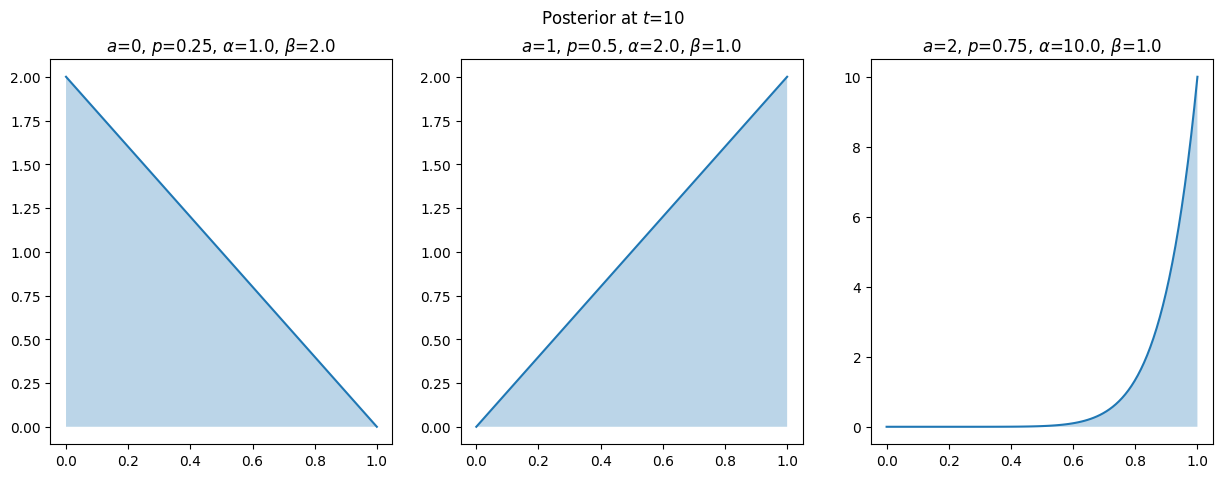

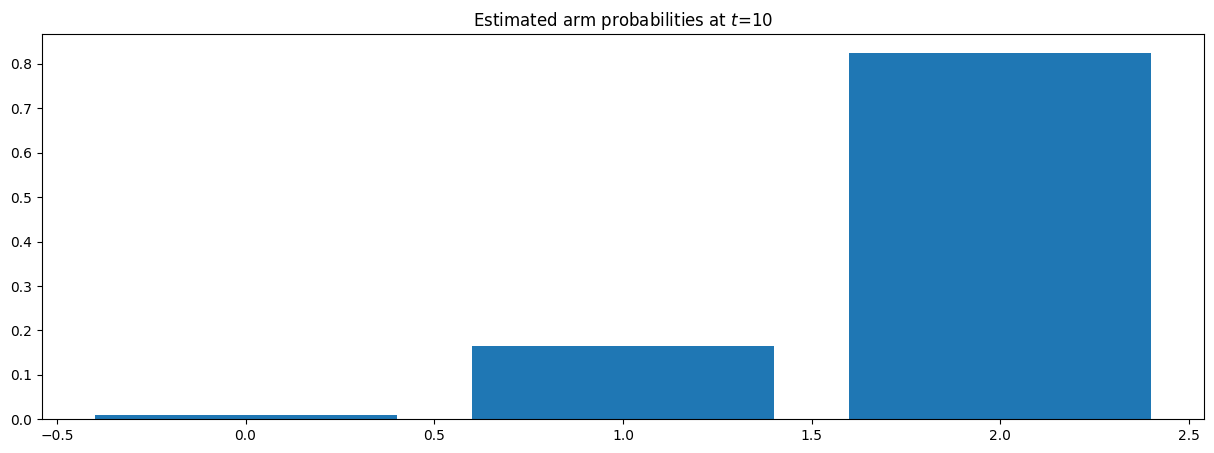

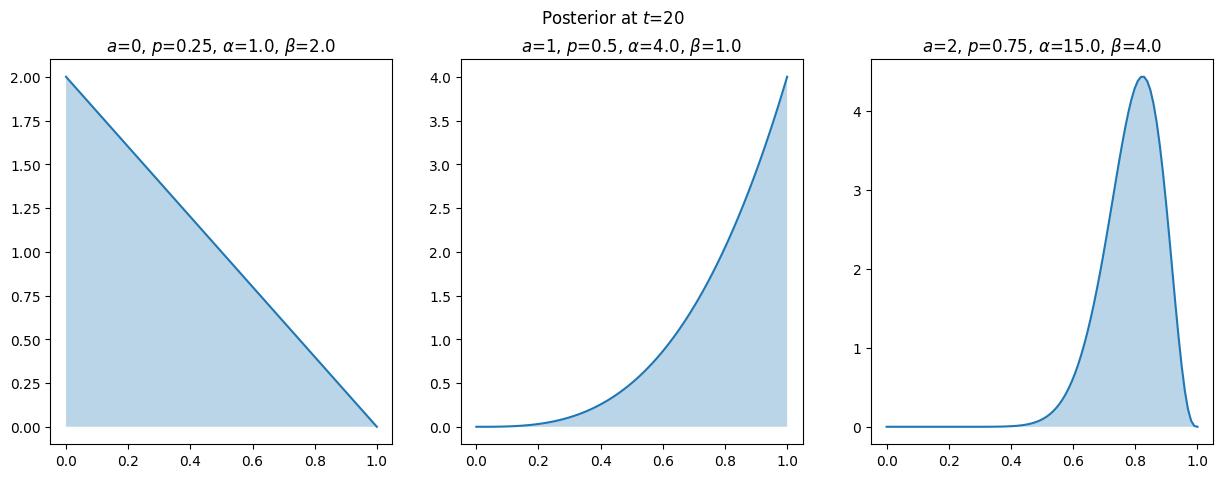

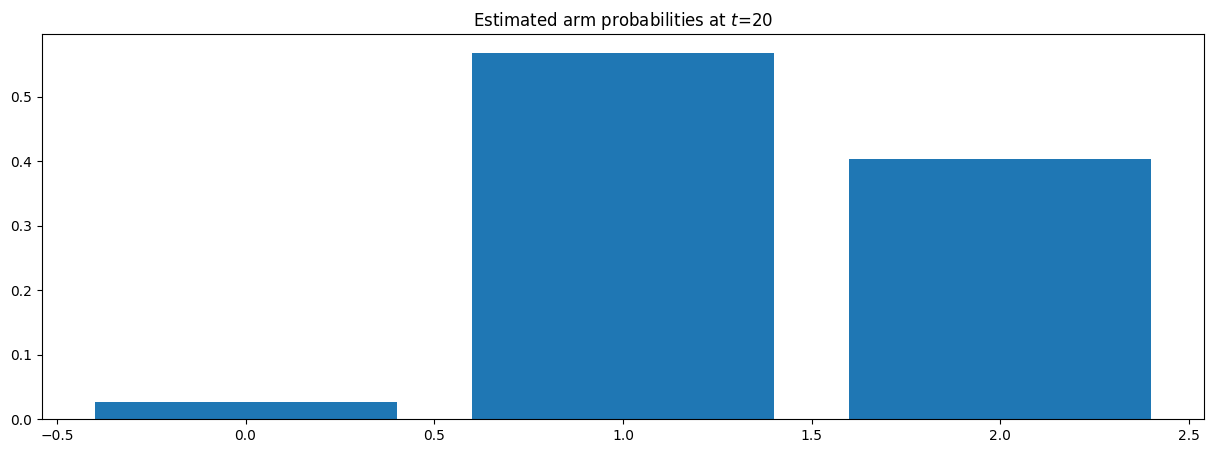

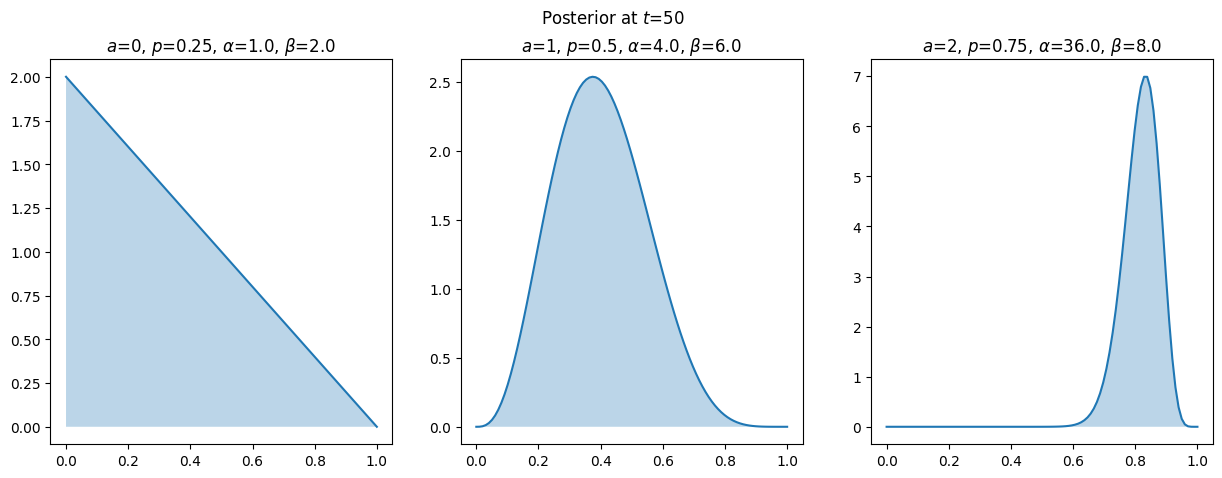

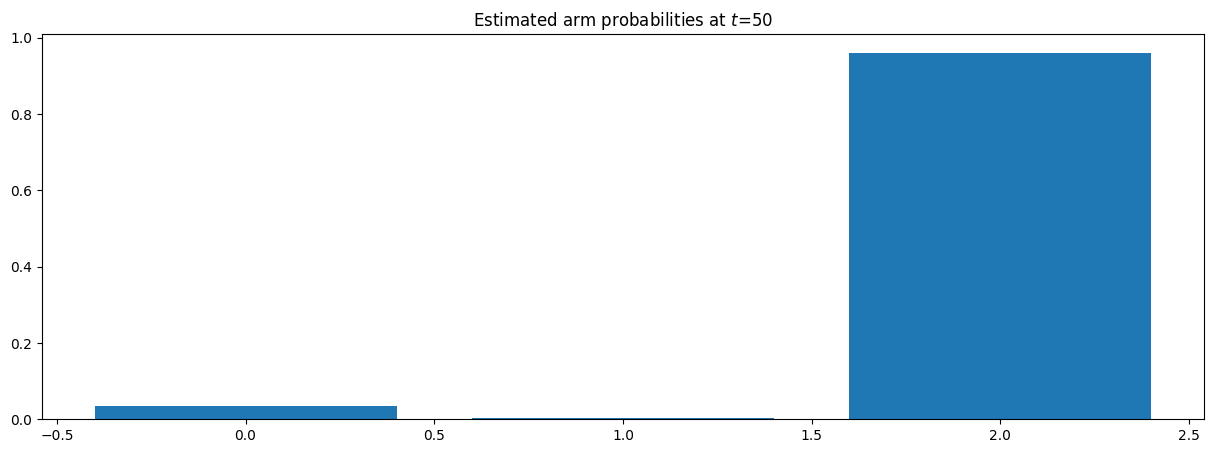

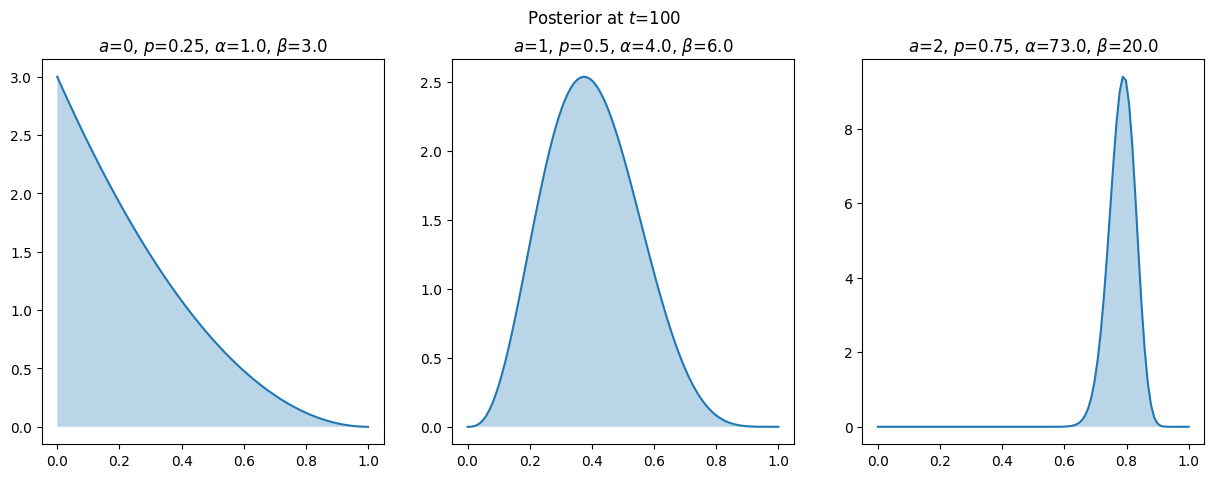

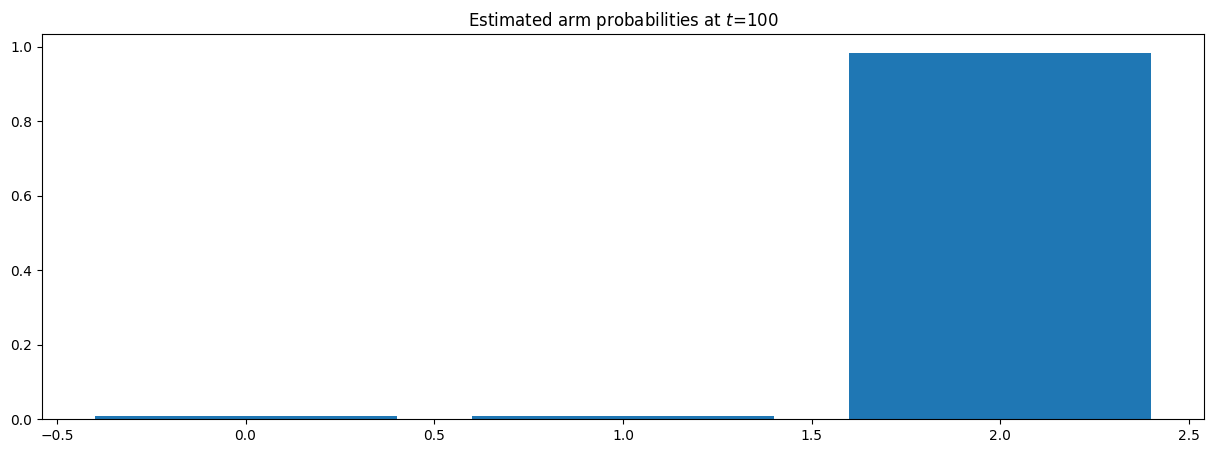

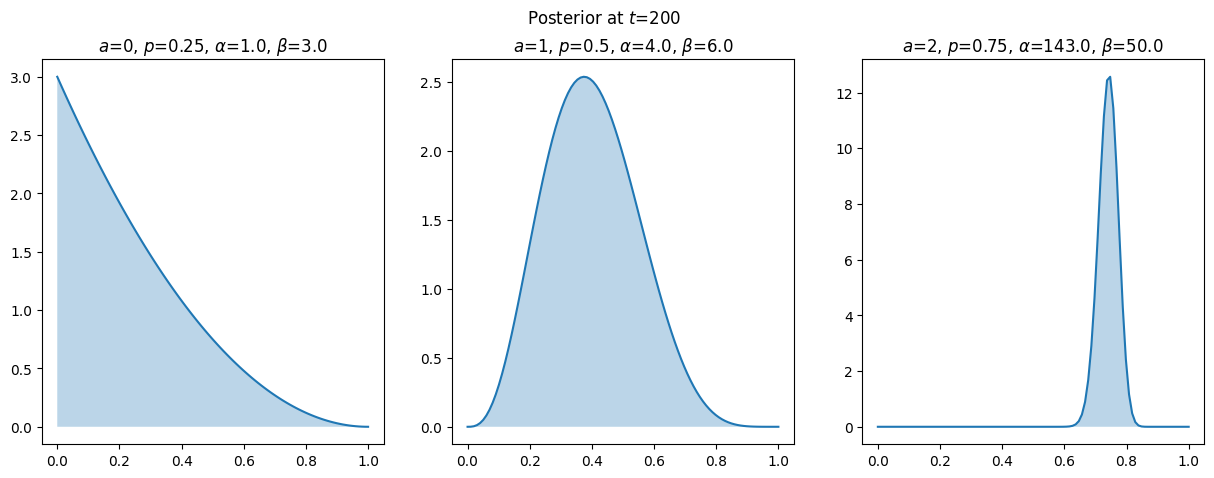

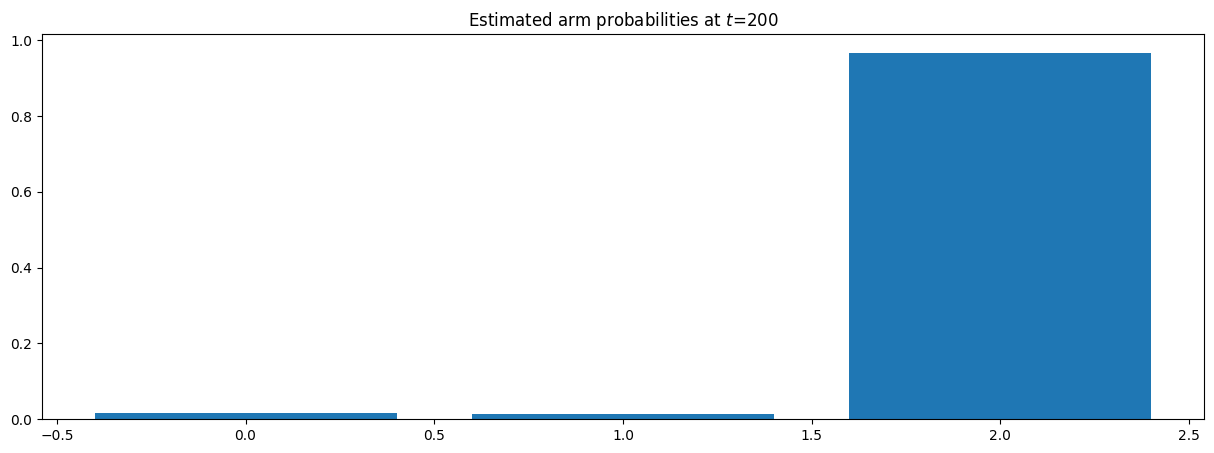

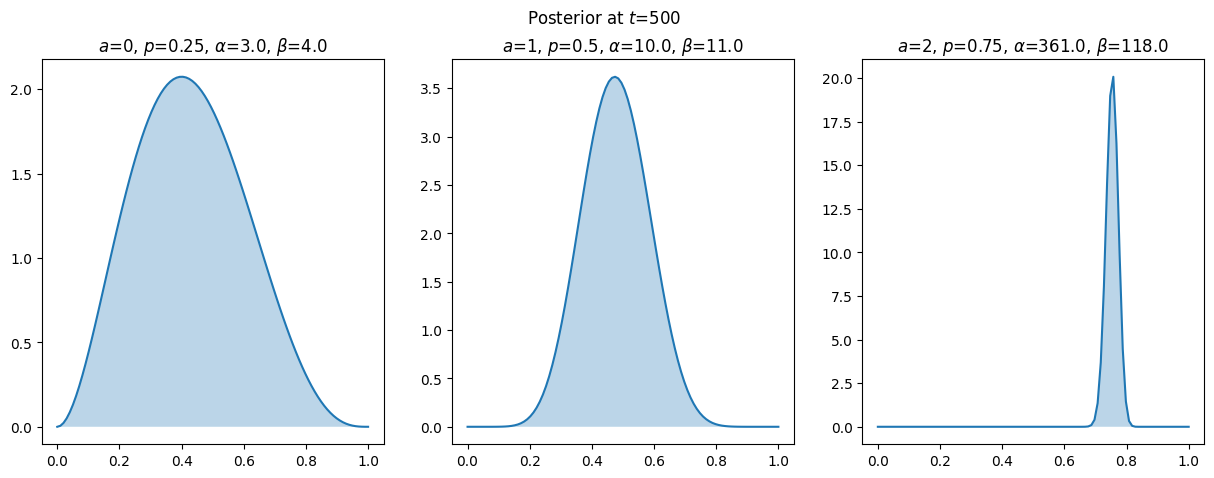

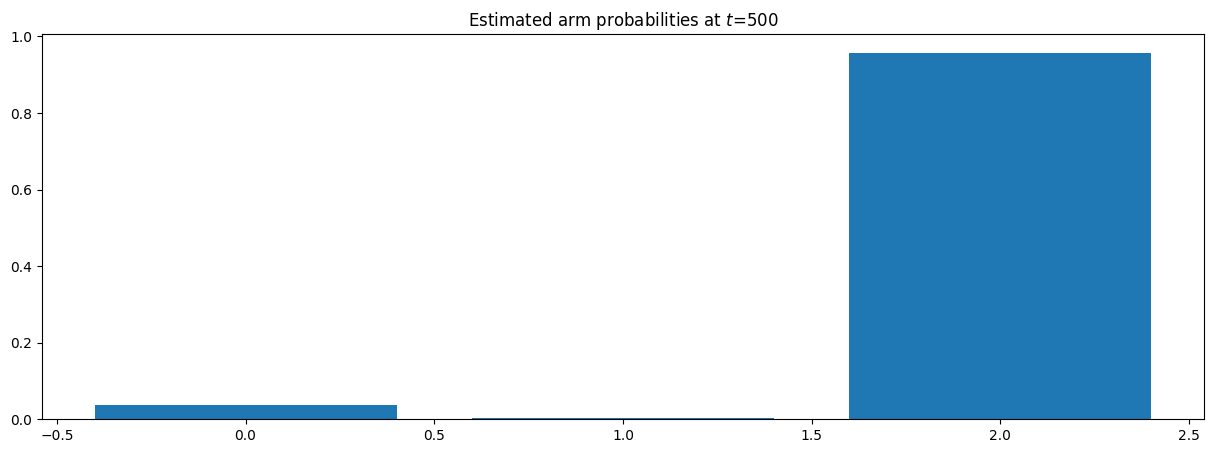

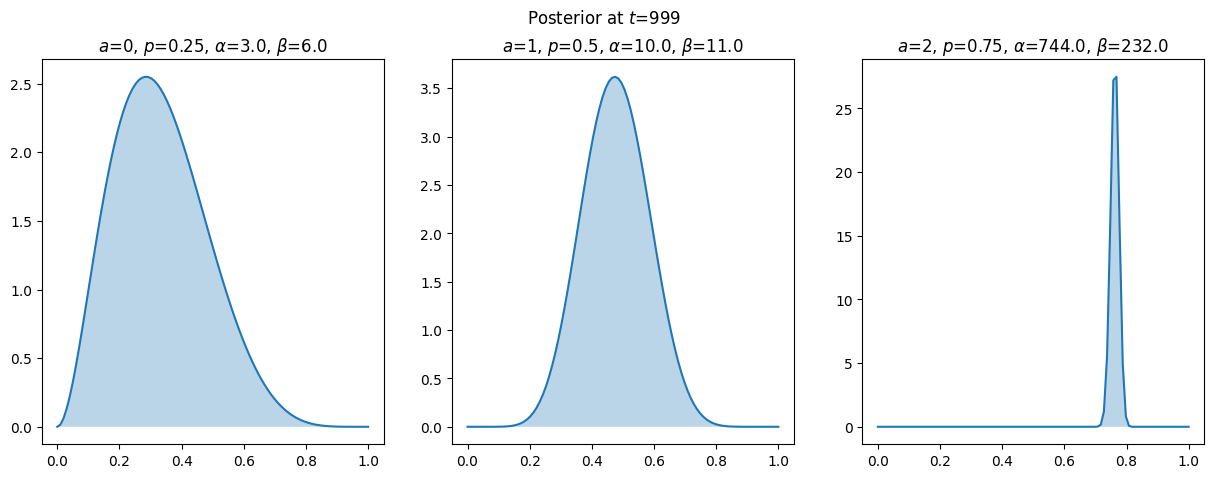

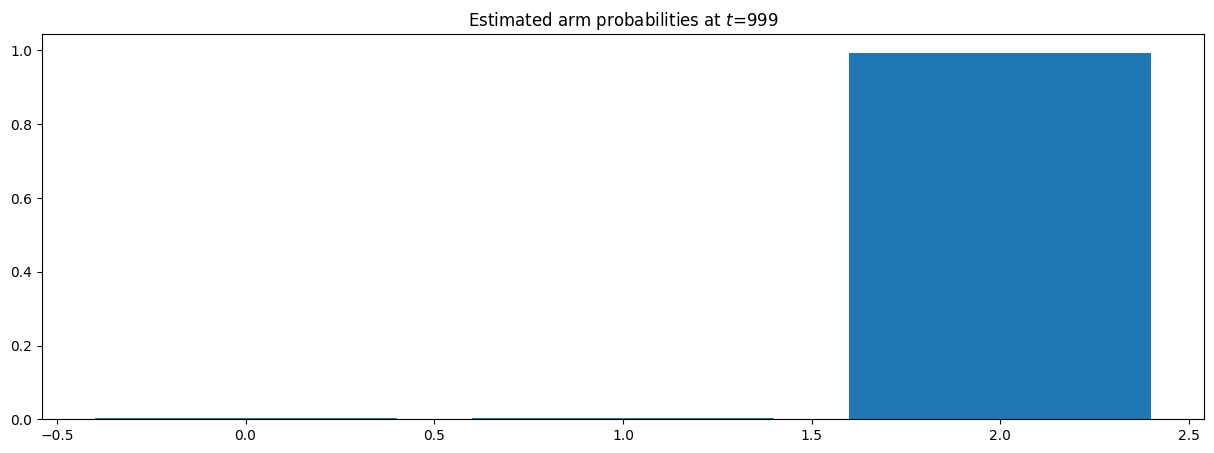

In [107]:
p = np.array([0.25, 0.5, 0.75])
K = len(p)
T = 1000
seed=85
np.random.seed(seed)
env = BernoulliEnvironment(p, T)
ts_agent = TSAgent(K)


for t in range(T):
    a_t = ts_agent.pull_arm()
    r_t = env.round(a_t)
    ts_agent.update(r_t)

    posterior_alpha, posterior_beta = ts_agent.alpha, ts_agent.beta
    theta = ts_agent.theta[-1]

    if t in [10, 20, 50, 100, 200, 500, 999]:
        state = np.random.get_state() # avoids altering the agent

        fig, axes = plt.subplots(1, K,figsize=(15,5))
        fig.suptitle('Posterior at $t$={}'.format(t))
        for k in range(K):
            plot_beta(posterior_alpha[k], posterior_beta[k], axes[k])
            axes[k].set_title('$a$={}, $p$={}, $\u03B1$={}, $\u03B2$={}'.format(k,p[k],posterior_alpha[k],posterior_beta[k]))
        plt.show()

        samples = np.stack([np.random.beta(posterior_alpha[k], posterior_beta[k], 10000) for k in range(K)])
        sampled_arms = np.argmax(samples, axis=0)
        n_pulls = [np.sum(sampled_arms==k)/len(sampled_arms) for k in range(K)]
        plt.figure(figsize=(15, 5))
        plt.title('Estimated arm probabilities at $t$={}'.format(t))
        plt.bar([k for k in range(K)], n_pulls)
        plt.show()

        np.random.set_state(state)

## UCB1 vs Thompson Sampling

### Let's compare UCB1 and TS

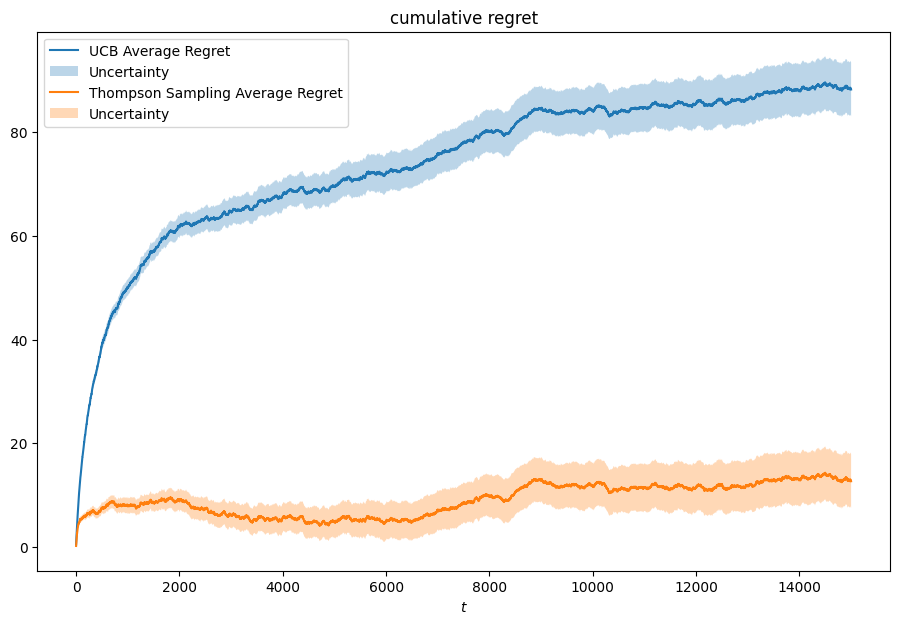

In [109]:
### Same block of code as in Exercise session 1!
p = np.array([0.25, 0.5, 0.75])
K = len(p)
best_action = np.argmax(p)
T = 15000
expected_clairvoyant_rewards = np.repeat(p[best_action], T)

n_trials = 100

ucb_regret_per_trial = []
ts_regret_per_trial = []

for seed in range(n_trials):
    np.random.seed(seed)
    env = BernoulliEnvironment(p, T)
    ucb_agent = UCB1Agent(K, T)

    agent_rewards = np.array([])

    for t in range(T):
        a_t = ucb_agent.pull_arm()
        r_t = env.round(a_t)
        ucb_agent.update(r_t)

        agent_rewards = np.append(agent_rewards, r_t)

    cumulative_regret = np.cumsum(expected_clairvoyant_rewards-agent_rewards)
    ucb_regret_per_trial.append(cumulative_regret)

    np.random.seed(seed)
    env = BernoulliEnvironment(p, T)
    ts_agent = TSAgent(K)
    agent_rewards = np.array([])
    for t in range(T):
        a_t = ts_agent.pull_arm()
        r_t = env.round(a_t)
        ts_agent.update(r_t)

        agent_rewards = np.append(agent_rewards, r_t)

    cumulative_regret = np.cumsum(expected_clairvoyant_rewards-agent_rewards)
    ts_regret_per_trial.append(cumulative_regret)

ucb_regret_per_trial = np.array(ucb_regret_per_trial)
ts_regret_per_trial = np.array(ts_regret_per_trial)

ucb_average_regret = ucb_regret_per_trial.mean(axis=0)
ucb_regret_sd = ucb_regret_per_trial.std(axis=0)

ts_average_regret = ts_regret_per_trial.mean(axis=0)
ts_regret_sd = ts_regret_per_trial.std(axis=0)

plt.figure(figsize=(11,7))
plt.plot(np.arange(T), ucb_average_regret, label='UCB Average Regret')
plt.fill_between(np.arange(T),
                ucb_average_regret-ucb_regret_sd/np.sqrt(n_trials),
                ucb_average_regret+ucb_regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.plot(np.arange(T), ts_average_regret, label='Thompson Sampling Average Regret')
plt.fill_between(np.arange(T),
                ts_average_regret-ts_regret_sd/np.sqrt(n_trials),
                ts_average_regret+ts_regret_sd/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')

plt.title('cumulative regret')
plt.xlabel('$t$')
plt.legend()
plt.show();

### Remark: theoretical guarantees of UCB1 and TS are nearly the same. Moreover, TS theoretical guarantees can be proven by showing that this strategy implicitly does optimism, thus the underlying principles of the two algorithms are the same.

### Remark: TS can be used in any stochastic environment, however to move from Bernoulli distributed rewards to more general ones the algorithm needs some adjustments. 
### A good reference on coding TS for Gaussian rewards can be found here: https://gertjanvandenburg.com/blog/thompson_sampling/.
### For general [0,1]-supported random variables, there is a simple adaptation, can you think of it?

In [ ]:
### Exercise: try to compare UCB1 and TS in a GaussianEnvironment

### Exercise: adapt TSAgent to work for every general [0,1]-supported random variable